In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):

    a : int
    b : int
    c : int 

    equation : str
    disc : float
    result : str
    

In [4]:
def show_equation(state: QuadState):

    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'

    return {'equation':equation}

def calculate_disc(state: QuadState):

    disc = state['b']**2 - 4*state['a']*state['c']

    return {'disc':disc}

In [ ]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_disc', calculate_disc)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

## edge 
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_disc')
graph.add_edge('calculate_disc', END)

workflow = graph.compile()

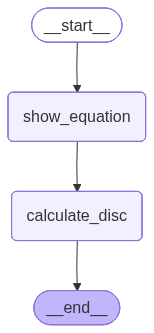

In [11]:
workflow

In [12]:
initial_state = {
    'a' : 4,
    'b' : -5,
    'c' : -4
}

workflow.invoke(initial_state)

{'a': 4, 'b': -5, 'c': -4, 'equation': '4x2-5x-4', 'disc': 89}